# BÀI TẬP LINEAR REGRESSION

Dự đoán giá nhà bằng mô hình hồi quy tuyến tính xây dựng với TensorFlow/Keras.

## 1. Khai báo thư viện và cấu hình tái lập

Thiết lập cùng một seed cho Python, NumPy và TensorFlow để kết quả huấn luyện có thể tái lập.

In [1]:
import os
import random
from pathlib import Path

# Giảm các thông báo hệ thống không cần thiết của TensorFlow.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Sequential

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

**Tóm tắt:** Cell trên tập trung toàn bộ import và seed ở một nơi. Điều này giúp notebook dễ cài đặt qua `requirements.txt` và hạn chế sai khác giữa các lần chạy.

## 2. Đọc và kiểm tra dữ liệu

Tập dữ liệu gồm 13 thuộc tính đầu vào và giá nhà trung vị `MEDV` làm biến mục tiêu.

In [2]:
COLUMN_NAMES = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
    "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV",
]
DATA_PATH = Path("data") / "housing.txt"

# Dữ liệu phân tách bằng một hoặc nhiều khoảng trắng và không có dòng tiêu đề.
df = pd.read_csv(DATA_PATH, sep=r"\s+", names=COLUMN_NAMES)

# Phát hiện sớm file sai cấu trúc hoặc dữ liệu bị thiếu trước khi huấn luyện.
assert df.shape[1] == len(COLUMN_NAMES), "Số cột dữ liệu không đúng như mong đợi."
assert not df.isna().any().any(), "Dữ liệu chứa giá trị thiếu."

print(f"Kích thước dữ liệu: {df.shape[0]} dòng x {df.shape[1]} cột")
display(df.head())

Kích thước dữ liệu: 506 dòng x 14 cột


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


**Tóm tắt:** File dữ liệu được đọc từ `data/housing.txt`, gán tên cột rõ nghĩa và kiểm tra cấu trúc trước khi dùng. Tập dữ liệu hợp lệ phải có 14 cột và không có giá trị thiếu.

## 3. Chia tập dữ liệu và chuẩn hóa

Dữ liệu được chia trước khi chuẩn hóa. Scaler chỉ học tham số từ tập train để không làm rò rỉ thông tin của tập test.

In [3]:
# Tách đặc trưng và biến mục tiêu.
X = df.drop(columns="MEDV")
y = df["MEDV"].to_numpy(dtype=np.float32)

# Giữ riêng 20% dữ liệu làm tập test độc lập.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE,
)

# Chỉ fit scaler trên tập train, sau đó dùng cùng phép biến đổi cho tập test.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw).astype(np.float32)
X_test = scaler.transform(X_test_raw).astype(np.float32)

print(f"Tập train: {X_train.shape}; tập test: {X_test.shape}")

Tập train: (404, 13); tập test: (102, 13)


**Tóm tắt:** 80% dữ liệu dùng để huấn luyện và 20% dùng để kiểm thử. Việc fit `StandardScaler` trên train vừa giúp tối ưu hội tụ ổn định, vừa giữ tập test hoàn toàn độc lập.

## 4. Xây dựng và huấn luyện mô hình

Mô hình chỉ có một neuron đầu ra với activation tuyến tính. Không dùng hidden layer để giữ đúng bản chất của linear regression.

In [4]:
# Một tầng Dense tuyến tính tương đương công thức y = Xw + b.
model = Sequential(
    [
        Input(shape=(X_train.shape[1],), name="features"),
        Dense(1, activation="linear", name="house_price"),
    ],
    name="linear_regression",
)

model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.05),
    loss="mse",
    metrics=["mae"],
)
model.summary()

Model: "linear_regression"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ house_price (Dense)             │ (None, 1)              │            14 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14 (56.00 B)

 Trainable params: 14 (56.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Dùng full-batch gradient descent vì bài toán tuyến tính có hàm mất mát lồi.
history = model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=len(X_train),
    verbose=0,
)

print(
    f"Đã chạy {len(history.history['loss'])} epoch; "
    f"MSE train cuối: {history.history['loss'][-1]:.4f}"
)

Đã chạy 1000 epoch; MSE train cuối: 21.6414


**Tóm tắt:** Mô hình học một hệ số cho mỗi đặc trưng và một hệ số chệch. Full-batch SGD phù hợp với hàm MSE lồi của hồi quy tuyến tính và hội tụ ổn định về nghiệm tối ưu.

## 5. Đánh giá trên tập test

Dùng đồng thời MAE, MSE, RMSE và R² để nhìn cả độ lớn sai số lẫn tỷ lệ phương sai được mô hình giải thích.

In [6]:
# Chỉ dự đoán tập test chưa từng được dùng để fit mô hình hoặc scaler.
y_pred = model.predict(X_test, verbose=0).ravel()

test_mae = mean_absolute_error(y_test, y_pred)
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred)

metrics = pd.Series(
    {"MAE": test_mae, "MSE": test_mse, "RMSE": test_rmse, "R²": test_r2},
    name="Giá trị",
).to_frame()
display(metrics.round(4))

,Giá trị
MAE,3.1892
MSE,24.2931
RMSE,4.9288
R²,0.6687


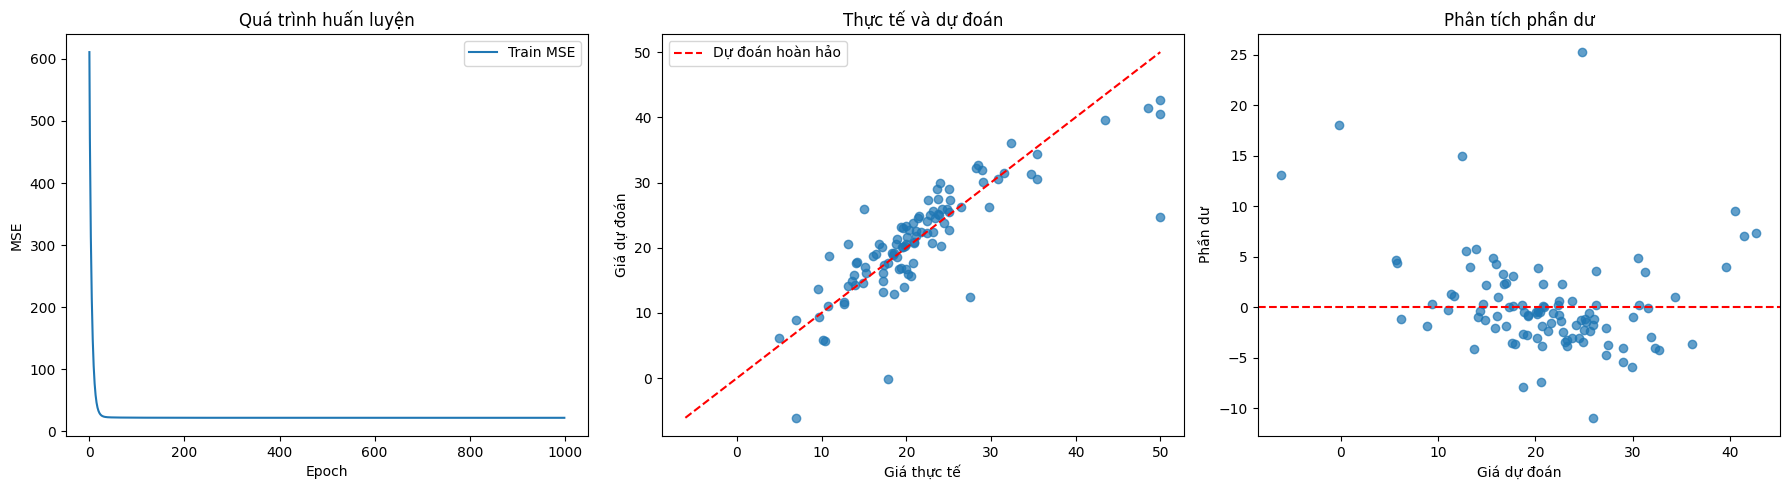

In [7]:
# Trực quan hóa quá trình học, độ khớp dự đoán và phân bố phần dư.
residuals = y_test - y_pred
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history["loss"], label="Train MSE")
axes[0].set(title="Quá trình huấn luyện", xlabel="Epoch", ylabel="MSE")
axes[0].legend()

lower = min(y_test.min(), y_pred.min())
upper = max(y_test.max(), y_pred.max())
axes[1].scatter(y_test, y_pred, alpha=0.7)
axes[1].plot([lower, upper], [lower, upper], "r--", label="Dự đoán hoàn hảo")
axes[1].set(title="Thực tế và dự đoán", xlabel="Giá thực tế", ylabel="Giá dự đoán")
axes[1].legend()

axes[2].scatter(y_pred, residuals, alpha=0.7)
axes[2].axhline(0, color="red", linestyle="--")
axes[2].set(title="Phân tích phần dư", xlabel="Giá dự đoán", ylabel="Phần dư")

plt.tight_layout()
plt.show()

## Tổng kết

- Pipeline đã tách train/test trước khi chuẩn hóa nên không làm rò rỉ dữ liệu.
- Mô hình là hồi quy tuyến tính đúng nghĩa với một tầng đầu ra tuyến tính.
- Các chỉ số được tính trên tập test độc lập; R² càng gần 1 và MAE/RMSE càng nhỏ thì dự đoán càng tốt.
- Biểu đồ phần dư hỗ trợ phát hiện sai số có cấu trúc mà các chỉ số tổng hợp có thể không thể hiện hết.